In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset


In [2]:
data_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44'

In [ ]:
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(5, 3),dpi=200)
model_name_list = ['AnyNet_L', 'ViT_L', 'RNN_L', 'LC_L']
for model_ii, model_name in enumerate(model_name_list):
    epoch0 = torch.load(data_dir + f'/Model/Allen/{model_name}_Allen_stimOff_times_epoch0.pt')
    train_acu = torch.load(data_dir + f'/Model/Allen/{model_name}_Allen_stimOff_times_train_acu0.pt')
    valid_acu = torch.load(data_dir + f'/Model/Allen/{model_name}_Allen_stimOff_times_valid_acu0.pt')
    plt.plot(train_acu, '--', color=color_list[model_ii], linewidth=2)
    plt.plot(valid_acu, '-', color=color_list[model_ii], linewidth=2, label=model_name)
    plt.plot(epoch0, valid_acu[epoch0], 'o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
sns.despine()
plt.legend()
plt.show()

In [42]:
data_dict = {}
model_name_list = ['AnyNet_L', 'ViT_L', 'RNN_L', 'LC_L']
train_valid = ['train', 'valid']
time_list = []
condition_list = []
name_list = []
epoch_list = []
for model_ii, model_name in enumerate(model_name_list):
    for condition in train_valid:
        try:
            data = torch.load(data_dir + f'/Model/Allen/{model_name}_time_array_{condition}_stimOff_times_0.pt')
        except:
            data = torch.load(data_dir + f'/Model/Allen/{model_name}_time_array_{condition}_stimOff_times_0.py')

        for epoch in range(0, 50):
            time_list.append(data[epoch])
            condition_list.append(condition)
            name_list.append(model_name)
            epoch_list.append(epoch)

data_dict['time'] = np.array(time_list)
data_dict['condition'] = np.array(condition_list)
data_dict['name'] = np.array(name_list)
data_dict['epoch'] = np.array(epoch_list)
data_dict = pd.DataFrame(data_dict)

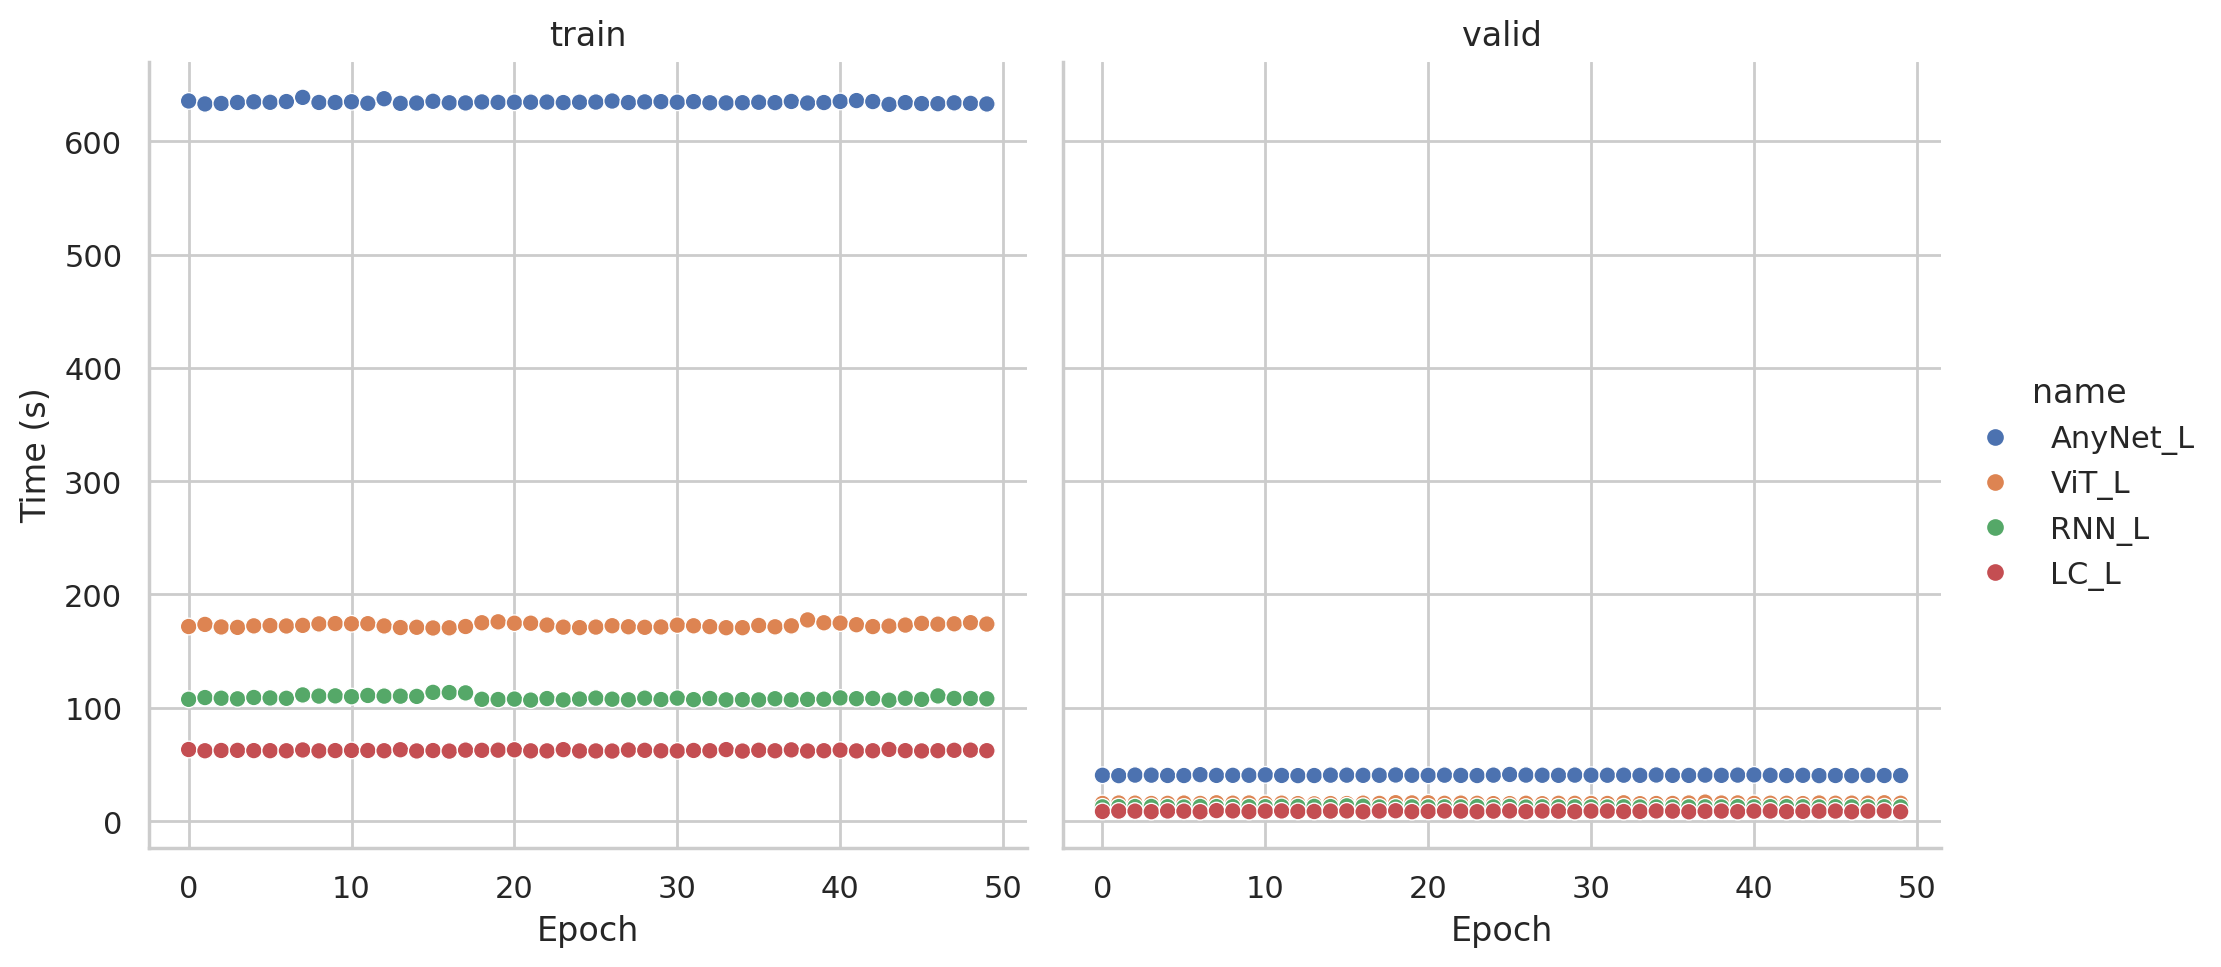

In [48]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
g = sns.relplot(data=data_dict, x='epoch', y='time', col='condition', hue='name')
g.set_ylabels('Time (s)')
g.set_xlabels('Epoch')
g.set_titles('{col_name}')